In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper

In [5]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=250)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [6]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=1,doc_content_chars_max=250)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [7]:
tools=[wiki,arxiv]

In [8]:
## Custom tools[RAG Tool]
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

d:\GenAI_Practice\Practice_LangchainProjects\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [9]:
loader=WebBaseLoader("https://docs.smith.langchain.com/")
docs=loader.load()
documents=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200).split_documents(docs)
vectordb=FAISS.from_documents(documents,OpenAIEmbeddings())
retriever=vectordb.as_retriever()
retriever

VectorStoreRetriever(tags=['FAISS', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x00000226F931E050>, search_kwargs={})

In [15]:
from langchain_core.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever,
    name="langsmith-search",
    description="Search any information about LangSmith"
)

print(retriever_tool.name)

langsmith-search


In [16]:
tools=[wiki,arxiv,retriever_tool]

In [17]:
## Run all this tools with Agents and LLM Models

## Tools, LLM-->AgentExecutor
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import openai
load_dotenv()
import os

groq_api_key=os.getenv("GROQ_API_KEY")
openai.api_key=os.getenv("OPENAI_API_KEY")

llm=ChatGroq(groq_api_key=groq_api_key,model_name="llama-3.1-8b-instant")

In [23]:
## Prompt Template
from langsmith import Client

client = Client()

prompt = client.pull_prompt("hwchase17/openai-functions-agent")
prompt.messages

[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are a helpful assistant'), additional_kwargs={}),
 MessagesPlaceholder(variable_name='chat_history', optional=True),
 HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}'), additional_kwargs={}),
 MessagesPlaceholder(variable_name='agent_scratchpad')]

In [39]:
system_prompt = """
You are a helpful assistant.
Only use the tools provided to you.
Do not invent tool names.
If no relevant tool exists, answer directly.
"""

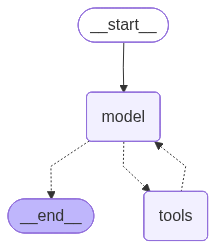

In [40]:
## Agents
from langchain.agents import create_agent
agent=create_agent(model=llm,tools=tools,system_prompt=system_prompt)
agent

In [57]:
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "what is transformer"}
    ]
})

d:\GenAI_Practice\Practice_LangchainProjects\venv\lib\site-packages\langchain_community\utilities\arxiv.py:105: DeprecationWarning: The 'Search.results' method is deprecated, use 'Client.results' instead
  ).results()


In [58]:
import pprint
pprint.pprint(response)

{'messages': [HumanMessage(content='what is transformer', additional_kwargs={}, response_metadata={}, id='5984306f-cb66-440b-a3db-aa435f94962b'),
              AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 't4zd0rh1t', 'function': {'arguments': '{"query":"transformer (machine learning)"}', 'name': 'wikipedia'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 525, 'total_tokens': 543, 'completion_time': 0.055873005, 'completion_tokens_details': None, 'prompt_time': 0.043202993, 'prompt_tokens_details': None, 'queue_time': 0.056446911, 'total_time': 0.099075998}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c4e01-0207-7bb1-91ca-5261d1063b81-0', tool_calls=[{'name': 'wikipedia', 'args': {'query': 'transformer (machine learning)'}, 'id': 't4zd0rh1t', 'type': 'tool_call'}],

In [59]:
for step in agent.stream(
    {"messages": [{"role": "user", "content": "Tell me about LangSmith"}]}
):
    print(step)

{'model': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 's6c72ysq5', 'function': {'arguments': '{"query":"LangSmith information"}', 'name': 'langsmith-search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 527, 'total_tokens': 545, 'completion_time': 0.01889349, 'completion_tokens_details': None, 'prompt_time': 0.045249632, 'prompt_tokens_details': None, 'queue_time': 0.047381568, 'total_time': 0.064143122}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c4e01-482b-73f2-99c9-ef51383dee4c-0', tool_calls=[{'name': 'langsmith-search', 'args': {'query': 'LangSmith information'}, 'id': 's6c72ysq5', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 527, 'output_tokens': 18, 'total_tokens': 545})]}}
{'tools': {'messages': [ToolMessag

In [60]:
for msg in response["messages"]:
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        for call in msg.tool_calls:
            print("Tool used:", call["name"])
            print("Arguments:", call["args"])

Tool used: wikipedia
Arguments: {'query': 'transformer (machine learning)'}
Tool used: arxiv
Arguments: {'query': 'transformer (deep learning)'}
